In [2]:
import pandas as pd
import numpy as np
import pickle
import warnings
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split

In [3]:
results = []

In [4]:
warnings.filterwarnings("ignore")

# Processed feature dataset
FEATURES_PATH = r"D:\SJU\ML assn\CallConnect\data\processed\features.csv"

# Load features
df = pd.read_csv(FEATURES_PATH)

print("Dataset shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nEmotion distribution:")
print(df["emotion"].value_counts())

Dataset shape: (1440, 183)

Columns: ['file_path', 'actor_id', 'emotion', 'mfcc_0', 'mfcc_1', 'mfcc_2', 'mfcc_3', 'mfcc_4', 'mfcc_5', 'mfcc_6', 'mfcc_7', 'mfcc_8', 'mfcc_9', 'mfcc_10', 'mfcc_11', 'mfcc_12', 'mfcc_13', 'mfcc_14', 'mfcc_15', 'mfcc_16', 'mfcc_17', 'mfcc_18', 'mfcc_19', 'mfcc_20', 'mfcc_21', 'mfcc_22', 'mfcc_23', 'mfcc_24', 'mfcc_25', 'mfcc_26', 'mfcc_27', 'mfcc_28', 'mfcc_29', 'mfcc_30', 'mfcc_31', 'mfcc_32', 'mfcc_33', 'mfcc_34', 'mfcc_35', 'mfcc_36', 'mfcc_37', 'mfcc_38', 'mfcc_39', 'chroma_0', 'chroma_1', 'chroma_2', 'chroma_3', 'chroma_4', 'chroma_5', 'chroma_6', 'chroma_7', 'chroma_8', 'chroma_9', 'chroma_10', 'chroma_11', 'mel_0', 'mel_1', 'mel_2', 'mel_3', 'mel_4', 'mel_5', 'mel_6', 'mel_7', 'mel_8', 'mel_9', 'mel_10', 'mel_11', 'mel_12', 'mel_13', 'mel_14', 'mel_15', 'mel_16', 'mel_17', 'mel_18', 'mel_19', 'mel_20', 'mel_21', 'mel_22', 'mel_23', 'mel_24', 'mel_25', 'mel_26', 'mel_27', 'mel_28', 'mel_29', 'mel_30', 'mel_31', 'mel_32', 'mel_33', 'mel_34', 'mel_35', 

In [5]:
from sklearn.model_selection import train_test_split

# Features: exclude metadata and target
feature_columns = [
    col for col in df.columns
    if col not in ["file_path", "actor_id", "emotion"]
]

X = df[feature_columns]
y = df["emotion"]

# 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Test samples:", X_test.shape[0])

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTest class distribution:")
print(y_test.value_counts())

Training samples: 1152
Test samples: 288

Training class distribution:
emotion
disgust      154
angry        154
sad          154
calm         154
happy        153
surprised    153
fearful      153
neutral       77
Name: count, dtype: int64

Test class distribution:
emotion
happy        39
fearful      39
surprised    39
sad          38
calm         38
angry        38
disgust      38
neutral      19
Name: count, dtype: int64


# SVM

In [6]:
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# SVM pipeline
svm_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(
        kernel="rbf",
        C=10,
        gamma="scale"
    ))
])

# 5-fold cross-validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision_macro",
    "recall": "recall_macro",
    "f1": "f1_macro"
}

svm_cv = cross_validate(
    svm_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    return_train_score=True,
    n_jobs=-1
)

# CV results
cv_train_acc = svm_cv["train_accuracy"].mean()
cv_accuracy = svm_cv["test_accuracy"].mean()
cv_precision = svm_cv["test_precision"].mean()
cv_recall = svm_cv["test_recall"].mean()
cv_f1 = svm_cv["test_f1"].mean()

# Fit final SVM on complete training set
svm_pipeline.fit(X_train, y_train)

# Predictions
y_train_pred = svm_pipeline.predict(X_train)
y_test_pred = svm_pipeline.predict(X_test)

# Final metrics
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(
    y_test, y_test_pred, average="macro"
)
test_recall = recall_score(
    y_test, y_test_pred, average="macro"
)
test_f1 = f1_score(
    y_test, y_test_pred, average="macro"
)

print("SVM (RBF, C=10)")
print("=" * 50)

print(f"Training Accuracy:  {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
print(f"CV Accuracy:        {cv_accuracy:.4f} ({cv_accuracy*100:.2f}%)")
print(f"Test Accuracy:      {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

print(f"\nCV Macro F1:        {cv_f1:.4f}")
print(f"Test Macro F1:      {test_f1:.4f}")
print(f"Test Macro Precision: {test_precision:.4f}")
print(f"Test Macro Recall:    {test_recall:.4f}")

print(f"\nTrain-Test Gap:      {(train_accuracy-test_accuracy)*100:.2f}%")

# Store results
results.append({
    "Model": "SVM (RBF)",
    "Training Accuracy": train_accuracy,
    "CV Accuracy": cv_accuracy,
    "Test Accuracy": test_accuracy,
    "CV Macro F1": cv_f1,
    "Test Macro F1": test_f1,
    "Test Macro Precision": test_precision,
    "Test Macro Recall": test_recall,
    "Train-Test Gap": train_accuracy - test_accuracy
})
print("\nResults stored successfully.")

SVM (RBF, C=10)
Training Accuracy:  0.9071 (90.71%)
CV Accuracy:        0.5938 (59.38%)
Test Accuracy:      0.6076 (60.76%)

CV Macro F1:        0.5765
Test Macro F1:      0.5876
Test Macro Precision: 0.6037
Test Macro Recall:    0.5895

Train-Test Gap:      29.95%

Results stored successfully.


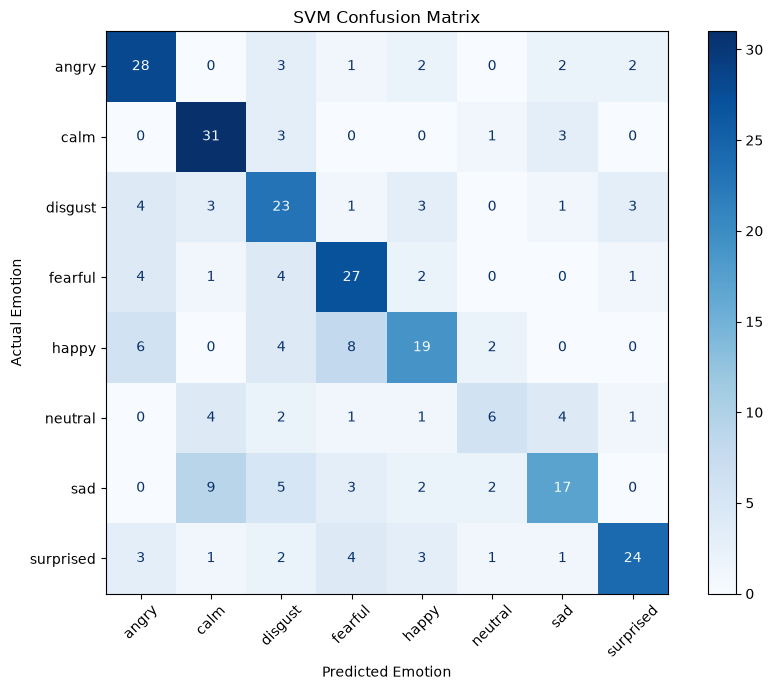

In [14]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Predictions on the test set
y_test_pred = svm_pipeline.predict(X_test)

# Confusion matrix
cm = confusion_matrix(y_test, y_test_pred)

# Class names in consistent order
classes = sorted(y_test.unique())

# Plot
fig, ax = plt.subplots(figsize=(9, 7))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=classes
)

disp.plot(
    ax=ax,
    cmap="Blues",
    values_format="d",
    xticks_rotation=45
)

plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted Emotion")
plt.ylabel("Actual Emotion")
plt.tight_layout()
plt.show()

# Logistic Regression

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Logistic Regression pipeline
logistic_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=2000,
        random_state=42
    ))
])

# 5-fold cross-validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision_macro",
    "recall": "recall_macro",
    "f1": "f1_macro"
}

logistic_cv = cross_validate(
    logistic_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    return_train_score=True,
    n_jobs=-1
)

# CV results
cv_train_acc = logistic_cv["train_accuracy"].mean()
cv_accuracy = logistic_cv["test_accuracy"].mean()
cv_precision = logistic_cv["test_precision"].mean()
cv_recall = logistic_cv["test_recall"].mean()
cv_f1 = logistic_cv["test_f1"].mean()

# Fit final Logistic Regression on complete training set
logistic_pipeline.fit(X_train, y_train)

# Predictions
y_train_pred = logistic_pipeline.predict(X_train)
y_test_pred = logistic_pipeline.predict(X_test)

# Final metrics
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

test_precision = precision_score(
    y_test,
    y_test_pred,
    average="macro"
)

test_recall = recall_score(
    y_test,
    y_test_pred,
    average="macro"
)

test_f1 = f1_score(
    y_test,
    y_test_pred,
    average="macro"
)

print("Logistic Regression")
print("=" * 50)

print(
    f"Training Accuracy:  {train_accuracy:.4f} "
    f"({train_accuracy*100:.2f}%)"
)

print(
    f"CV Accuracy:        {cv_accuracy:.4f} "
    f"({cv_accuracy*100:.2f}%)"
)

print(
    f"Test Accuracy:      {test_accuracy:.4f} "
    f"({test_accuracy*100:.2f}%)"
)

print(f"\nCV Macro F1:          {cv_f1:.4f}")
print(f"Test Macro F1:        {test_f1:.4f}")
print(f"Test Macro Precision: {test_precision:.4f}")
print(f"Test Macro Recall:    {test_recall:.4f}")

print(
    f"\nTrain-Test Gap:       "
    f"{(train_accuracy-test_accuracy)*100:.2f}%"
)

# Store Logistic Regression results
logistic_result = {
    "Model": "Logistic Regression",
    "Training Accuracy": train_accuracy,
    "CV Accuracy": cv_accuracy,
    "Test Accuracy": test_accuracy,
    "CV Macro F1": cv_f1,
    "Test Macro F1": test_f1,
    "Test Macro Precision": test_precision,
    "Test Macro Recall": test_recall,
    "Train-Test Gap": train_accuracy - test_accuracy
}

print("\nResults stored successfully.")

Logistic Regression
Training Accuracy:  0.7075 (70.75%)
CV Accuracy:        0.4731 (47.31%)
Test Accuracy:      0.4236 (42.36%)

CV Macro F1:          0.4561
Test Macro F1:        0.4142
Test Macro Precision: 0.4161
Test Macro Recall:    0.4141

Train-Test Gap:       28.39%

Results stored successfully.


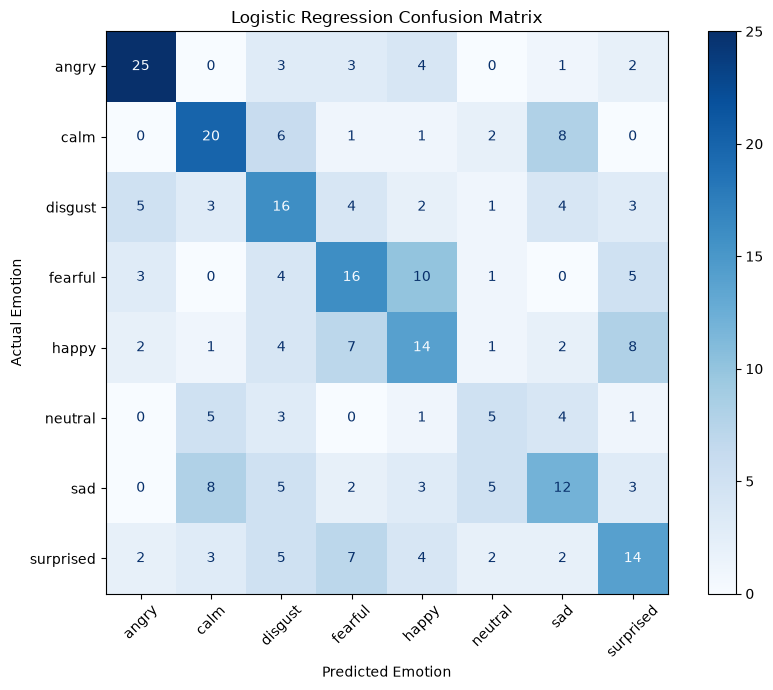


Logistic Regression Classification Report:
              precision    recall  f1-score   support

       angry       0.68      0.66      0.67        38
        calm       0.50      0.53      0.51        38
     disgust       0.35      0.42      0.38        38
     fearful       0.40      0.41      0.41        39
       happy       0.36      0.36      0.36        39
     neutral       0.29      0.26      0.28        19
         sad       0.36      0.32      0.34        38
   surprised       0.39      0.36      0.37        39

    accuracy                           0.42       288
   macro avg       0.42      0.41      0.41       288
weighted avg       0.42      0.42      0.42       288



In [17]:
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

# Predictions on the test set
y_test_pred = logistic_pipeline.predict(X_test)

# Class names in consistent order
classes = sorted(y_test.unique())

# Confusion matrix
cm = confusion_matrix(
    y_test,
    y_test_pred,
    labels=classes
)

# Plot
fig, ax = plt.subplots(figsize=(9, 7))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=classes
)

disp.plot(
    ax=ax,
    cmap="Blues",
    values_format="d",
    xticks_rotation=45
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted Emotion")
plt.ylabel("Actual Emotion")
plt.tight_layout()
plt.show()


# Classification report
print("\nLogistic Regression Classification Report:")
print(
    classification_report(
        y_test,
        y_test_pred,
        labels=classes,
        target_names=classes
    )
)

# Random Forest

In [24]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Random Forest
rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

# 5-fold cross-validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision_macro",
    "recall": "recall_macro",
    "f1": "f1_macro"
}

rf_cv = cross_validate(
    rf,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    return_train_score=True,
    n_jobs=-1
)

# CV results
cv_train_acc = rf_cv["train_accuracy"].mean()
cv_accuracy = rf_cv["test_accuracy"].mean()
cv_precision = rf_cv["test_precision"].mean()
cv_recall = rf_cv["test_recall"].mean()
cv_f1 = rf_cv["test_f1"].mean()

# Fit final Random Forest on complete training set
rf.fit(X_train, y_train)

# Predictions
y_train_pred = rf.predict(X_train)
y_test_pred = rf.predict(X_test)

# Final metrics
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

test_precision = precision_score(
    y_test,
    y_test_pred,
    average="macro"
)

test_recall = recall_score(
    y_test,
    y_test_pred,
    average="macro"
)

test_f1 = f1_score(
    y_test,
    y_test_pred,
    average="macro"
)

# Store results
results.append({
    "Model": "Random Forest",
    "Training Accuracy": train_accuracy,
    "CV Accuracy": cv_accuracy,
    "Test Accuracy": test_accuracy,
    "CV Macro F1": cv_f1,
    "Test Macro F1": test_f1,
    "Test Macro Precision": test_precision,
    "Test Macro Recall": test_recall,
    "Train-Test Gap": train_accuracy - test_accuracy
})

# Display results
print("Random Forest")
print("=" * 50)

print(
    f"Training Accuracy:    {train_accuracy:.4f} "
    f"({train_accuracy*100:.2f}%)"
)

print(
    f"CV Accuracy:          {cv_accuracy:.4f} "
    f"({cv_accuracy*100:.2f}%)"
)

print(
    f"Test Accuracy:        {test_accuracy:.4f} "
    f"({test_accuracy*100:.2f}%)"
)

print(f"\nCV Macro F1:          {cv_f1:.4f}")
print(f"Test Macro F1:        {test_f1:.4f}")
print(f"Test Macro Precision: {test_precision:.4f}")
print(f"Test Macro Recall:    {test_recall:.4f}")

print(
    f"\nTrain-Test Gap:       "
    f"{(train_accuracy-test_accuracy)*100:.2f}%"
)

print("\nResults stored successfully.")

Random Forest
Training Accuracy:    0.9939 (99.39%)
CV Accuracy:          0.4991 (49.91%)
Test Accuracy:        0.5035 (50.35%)

CV Macro F1:          0.4778
Test Macro F1:        0.4776
Test Macro Precision: 0.5251
Test Macro Recall:    0.4830

Train-Test Gap:       49.05%


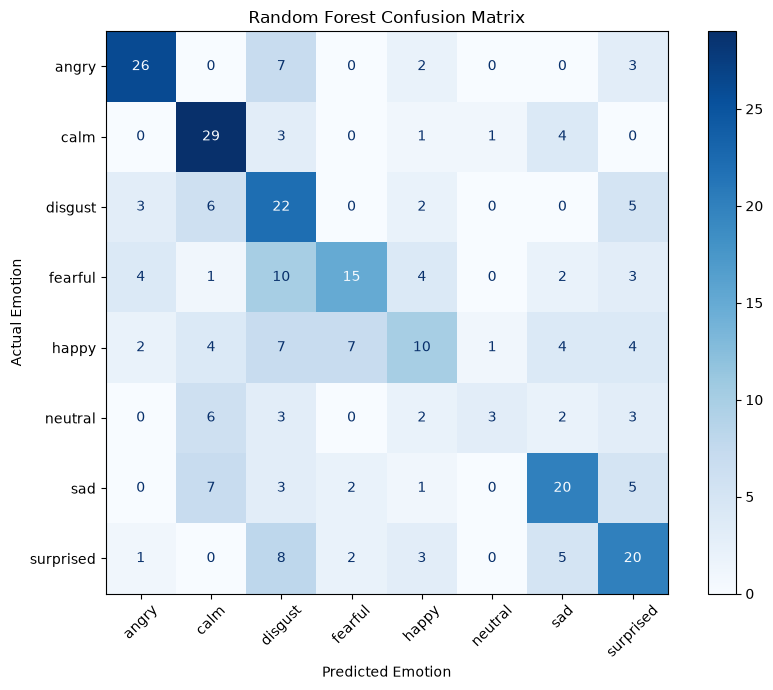

In [25]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Predictions
y_test_pred = rf.predict(X_test)

# Class order
classes = sorted(y_test.unique())

# Confusion matrix
cm = confusion_matrix(
    y_test,
    y_test_pred,
    labels=classes
)

# Plot
fig, ax = plt.subplots(figsize=(9, 7))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=classes
)

disp.plot(
    ax=ax,
    cmap="Blues",
    values_format="d",
    xticks_rotation=45
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted Emotion")
plt.ylabel("Actual Emotion")
plt.tight_layout()
plt.show()

# XG Classifier

In [26]:
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Encode emotion labels for XGBoost
encoder = LabelEncoder()

y_train_xgb = encoder.fit_transform(y_train)
y_test_xgb = encoder.transform(y_test)

print("Classes:")
for i, label in enumerate(encoder.classes_):
    print(i, "=", label)

# XGBoost model
xgb_model = XGBClassifier(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softmax",
    num_class=len(encoder.classes_),
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)

# 5-fold cross-validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision_macro",
    "recall": "recall_macro",
    "f1": "f1_macro"
}

xgb_cv = cross_validate(
    xgb_model,
    X_train,
    y_train_xgb,
    cv=cv,
    scoring=scoring,
    return_train_score=True,
    n_jobs=-1
)

# CV results
cv_train_acc = xgb_cv["train_accuracy"].mean()
cv_accuracy = xgb_cv["test_accuracy"].mean()
cv_precision = xgb_cv["test_precision"].mean()
cv_recall = xgb_cv["test_recall"].mean()
cv_f1 = xgb_cv["test_f1"].mean()

# Fit final XGBoost on complete training set
xgb_model.fit(X_train, y_train_xgb)

# Predictions
y_train_pred_xgb = xgb_model.predict(X_train)
y_test_pred_xgb = xgb_model.predict(X_test)

# Final metrics
train_accuracy = accuracy_score(
    y_train_xgb,
    y_train_pred_xgb
)

test_accuracy = accuracy_score(
    y_test_xgb,
    y_test_pred_xgb
)

test_precision = precision_score(
    y_test_xgb,
    y_test_pred_xgb,
    average="macro"
)

test_recall = recall_score(
    y_test_xgb,
    y_test_pred_xgb,
    average="macro"
)

test_f1 = f1_score(
    y_test_xgb,
    y_test_pred_xgb,
    average="macro"
)

# Store results
results.append({
    "Model": "XGBoost",
    "Training Accuracy": train_accuracy,
    "CV Accuracy": cv_accuracy,
    "Test Accuracy": test_accuracy,
    "CV Macro F1": cv_f1,
    "Test Macro F1": test_f1,
    "Test Macro Precision": test_precision,
    "Test Macro Recall": test_recall,
    "Train-Test Gap": train_accuracy - test_accuracy
})
print("\nResults stored successfully.")

# Display results
print("\nXGBoost")
print("=" * 50)

print(
    f"Training Accuracy:    {train_accuracy:.4f} "
    f"({train_accuracy*100:.2f}%)"
)

print(
    f"CV Accuracy:          {cv_accuracy:.4f} "
    f"({cv_accuracy*100:.2f}%)"
)

print(
    f"Test Accuracy:        {test_accuracy:.4f} "
    f"({test_accuracy*100:.2f}%)"
)

print(f"\nCV Macro F1:          {cv_f1:.4f}")
print(f"Test Macro F1:        {test_f1:.4f}")
print(f"Test Macro Precision: {test_precision:.4f}")
print(f"Test Macro Recall:    {test_recall:.4f}")

print(
    f"\nTrain-Test Gap:       "
    f"{(train_accuracy-test_accuracy)*100:.2f}%"
)

Classes:
0 = angry
1 = calm
2 = disgust
3 = fearful
4 = happy
5 = neutral
6 = sad
7 = surprised

Results stored successfully.

XGBoost
Training Accuracy:    1.0000 (100.00%)
CV Accuracy:          0.5972 (59.72%)
Test Accuracy:        0.6493 (64.93%)

CV Macro F1:          0.5872
Test Macro F1:        0.6380
Test Macro Precision: 0.6447
Test Macro Recall:    0.6384

Train-Test Gap:       35.07%


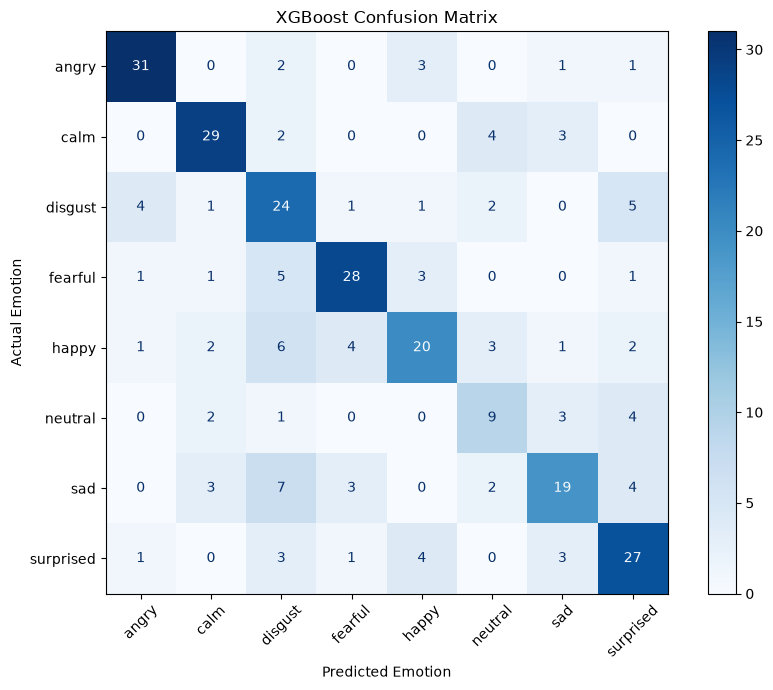


XGBoost Classification Report:
              precision    recall  f1-score   support

       angry       0.82      0.82      0.82        38
        calm       0.76      0.76      0.76        38
     disgust       0.48      0.63      0.55        38
     fearful       0.76      0.72      0.74        39
       happy       0.65      0.51      0.57        39
     neutral       0.45      0.47      0.46        19
         sad       0.63      0.50      0.56        38
   surprised       0.61      0.69      0.65        39

    accuracy                           0.65       288
   macro avg       0.64      0.64      0.64       288
weighted avg       0.66      0.65      0.65       288



In [29]:
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

# XGBoost test predictions are encoded integers
y_test_pred_xgb = xgb_model.predict(X_test)

# Class order
classes_xgb = encoder.classes_

# Confusion matrix
cm_xgb = confusion_matrix(
    y_test_xgb,
    y_test_pred_xgb,
    labels=range(len(classes_xgb))
)

# Plot
fig, ax = plt.subplots(figsize=(9, 7))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_xgb,
    display_labels=classes_xgb
)

disp.plot(
    ax=ax,
    cmap="Blues",
    values_format="d",
    xticks_rotation=45
)

plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted Emotion")
plt.ylabel("Actual Emotion")
plt.tight_layout()
plt.show()

# Classification report
print("\nXGBoost Classification Report:")
print(
    classification_report(
        y_test_xgb,
        y_test_pred_xgb,
        labels=range(len(classes_xgb)),
        target_names=classes_xgb
    )
)

# MLP Classifier

In [27]:
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# MLP pipeline
mlp_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", MLPClassifier(
        hidden_layer_sizes=(64, 32),
        alpha=1.0,
        batch_size=32,
        learning_rate="adaptive",
        max_iter=500,
        early_stopping=True,
        validation_fraction=0.15,
        n_iter_no_change=20,
        random_state=42
    ))
])

# 5-fold cross-validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision_macro",
    "recall": "recall_macro",
    "f1": "f1_macro"
}

mlp_cv = cross_validate(
    mlp_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    return_train_score=True,
    n_jobs=-1
)

# CV results
cv_train_acc = mlp_cv["train_accuracy"].mean()
cv_accuracy = mlp_cv["test_accuracy"].mean()
cv_precision = mlp_cv["test_precision"].mean()
cv_recall = mlp_cv["test_recall"].mean()
cv_f1 = mlp_cv["test_f1"].mean()

# Fit final MLP on complete training set
mlp_pipeline.fit(X_train, y_train)

# Predictions
y_train_pred = mlp_pipeline.predict(X_train)
y_test_pred = mlp_pipeline.predict(X_test)

# Final metrics
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

test_precision = precision_score(
    y_test,
    y_test_pred,
    average="macro"
)

test_recall = recall_score(
    y_test,
    y_test_pred,
    average="macro"
)

test_f1 = f1_score(
    y_test,
    y_test_pred,
    average="macro"
)

# Store results
results.append({
    "Model": "MLP",
    "Training Accuracy": train_accuracy,
    "CV Accuracy": cv_accuracy,
    "Test Accuracy": test_accuracy,
    "CV Macro F1": cv_f1,
    "Test Macro F1": test_f1,
    "Test Macro Precision": test_precision,
    "Test Macro Recall": test_recall,
    "Train-Test Gap": train_accuracy - test_accuracy
})

# Display results
print("MLP Neural Network")
print("=" * 50)

print(
    f"Training Accuracy:    {train_accuracy:.4f} "
    f"({train_accuracy*100:.2f}%)"
)

print(
    f"CV Accuracy:          {cv_accuracy:.4f} "
    f"({cv_accuracy*100:.2f}%)"
)

print(
    f"Test Accuracy:        {test_accuracy:.4f} "
    f"({test_accuracy*100:.2f}%)"
)

print(f"\nCV Macro F1:          {cv_f1:.4f}")
print(f"Test Macro F1:        {test_f1:.4f}")
print(f"Test Macro Precision: {test_precision:.4f}")
print(f"Test Macro Recall:    {test_recall:.4f}")

print(
    f"\nTrain-Test Gap:       "
    f"{(train_accuracy-test_accuracy)*100:.2f}%"
)

MLP Neural Network
Training Accuracy:    0.6528 (65.28%)
CV Accuracy:          0.5304 (53.04%)
Test Accuracy:        0.4757 (47.57%)

CV Macro F1:          0.4789
Test Macro F1:        0.4319
Test Macro Precision: 0.4435
Test Macro Recall:    0.4460

Train-Test Gap:       17.71%


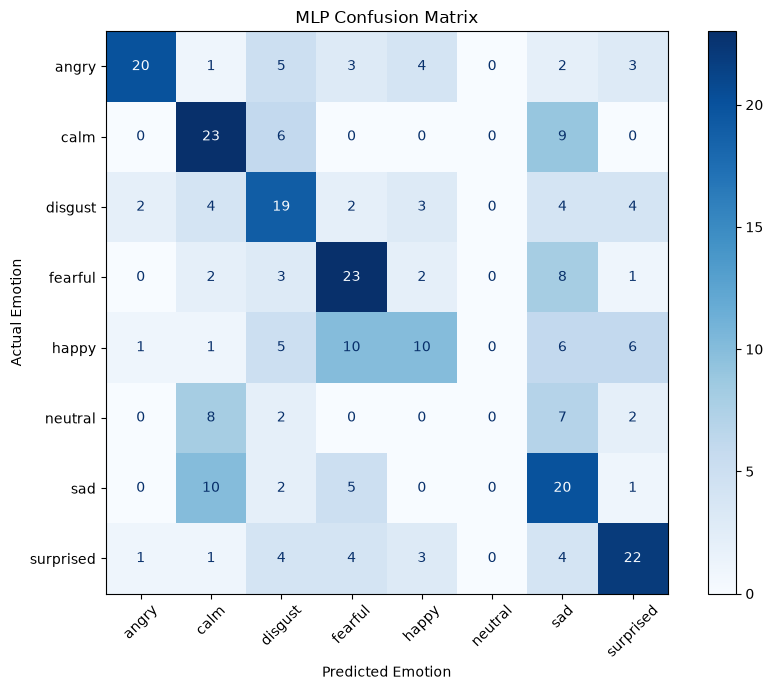


MLP Classification Report:
              precision    recall  f1-score   support

       angry       0.83      0.53      0.65        38
        calm       0.46      0.61      0.52        38
     disgust       0.41      0.50      0.45        38
     fearful       0.49      0.59      0.53        39
       happy       0.45      0.26      0.33        39
     neutral       0.00      0.00      0.00        19
         sad       0.33      0.53      0.41        38
   surprised       0.56      0.56      0.56        39

    accuracy                           0.48       288
   macro avg       0.44      0.45      0.43       288
weighted avg       0.47      0.48      0.46       288



In [30]:
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

# MLP test predictions
y_test_pred_mlp = mlp_pipeline.predict(X_test)

# Class order
classes_mlp = sorted(y_test.unique())

# Confusion matrix
cm_mlp = confusion_matrix(
    y_test,
    y_test_pred_mlp,
    labels=classes_mlp
)

# Plot
fig, ax = plt.subplots(figsize=(9, 7))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_mlp,
    display_labels=classes_mlp
)

disp.plot(
    ax=ax,
    cmap="Blues",
    values_format="d",
    xticks_rotation=45
)

plt.title("MLP Confusion Matrix")
plt.xlabel("Predicted Emotion")
plt.ylabel("Actual Emotion")
plt.tight_layout()
plt.show()

# Classification report
print("\nMLP Classification Report:")
print(
    classification_report(
        y_test,
        y_test_pred_mlp,
        labels=classes_mlp,
        target_names=classes_mlp
    )
)

# Final Analysis

In [31]:
import pandas as pd

comparison_df = pd.DataFrame(results)

# Convert metrics to percentages for easier reading
display_df = comparison_df.copy()

metric_columns = [
    "Training Accuracy",
    "CV Accuracy",
    "Test Accuracy",
    "CV Macro F1",
    "Test Macro F1",
    "Test Macro Precision",
    "Test Macro Recall",
    "Train-Test Gap"
]

for col in metric_columns:
    display_df[col] = display_df[col] * 100

display_df = display_df.round(2)

print("FINAL MODEL COMPARISON")
print("=" * 100)
print(display_df.to_string(index=False))

FINAL MODEL COMPARISON
        Model  Training Accuracy  CV Accuracy  Test Accuracy  CV Macro F1  Test Macro F1  Test Macro Precision  Test Macro Recall  Train-Test Gap
    SVM (RBF)              90.71        59.38          60.76        57.65          58.76                 60.37              58.95           29.95
Random Forest              99.39        49.91          50.35        47.78          47.76                 52.51              48.30           49.05
      XGBoost             100.00        59.72          64.93        58.72          63.80                 64.47              63.84           35.07
          MLP              65.28        53.04          47.57        47.89          43.19                 44.35              44.60           17.71


# Fine Tuning

## Fine Tuning SVM Parameters

In [7]:
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# --------------------------------------------------
# SVM PIPELINE
# --------------------------------------------------

svm_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC())
])

# --------------------------------------------------
# PARAMETER GRID
# --------------------------------------------------

param_grid = {
    "model__C": [0.1, 1, 10, 100, 1000],
    "model__gamma": [1, 0.1, 0.01, 0.001, 0.0001],
    "model__kernel": ["rbf"]
}

# --------------------------------------------------
# 5-FOLD STRATIFIED CV
# --------------------------------------------------

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# --------------------------------------------------
# GRID SEARCH
# --------------------------------------------------

grid = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=cv,
    refit=True,
    verbose=3,
    n_jobs=-1
)

# Train
grid.fit(X_train, y_train)

# --------------------------------------------------
# BEST PARAMETERS
# --------------------------------------------------

print("\nBEST PARAMETERS:")
print(grid.best_params_)

print("\nBEST CV MACRO F1:")
print(f"{grid.best_score_:.4f}")
print(f"{grid.best_score_ * 100:.2f}%")

Fitting 5 folds for each of 25 candidates, totalling 125 fits

BEST PARAMETERS:
{'model__C': 10, 'model__gamma': 0.01, 'model__kernel': 'rbf'}

BEST CV MACRO F1:
0.6123
61.23%


## Tuned SVM Model

In [8]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# Best tuned SVM
best_svm = grid.best_estimator_

# Predictions
y_train_pred_tuned = best_svm.predict(X_train)
y_test_pred_tuned = best_svm.predict(X_test)

# Metrics
train_accuracy_tuned = accuracy_score(
    y_train, y_train_pred_tuned
)

test_accuracy_tuned = accuracy_score(
    y_test, y_test_pred_tuned
)

test_precision_tuned = precision_score(
    y_test,
    y_test_pred_tuned,
    average="macro"
)

test_recall_tuned = recall_score(
    y_test,
    y_test_pred_tuned,
    average="macro"
)

test_f1_tuned = f1_score(
    y_test,
    y_test_pred_tuned,
    average="macro"
)

train_test_gap_tuned = (
    train_accuracy_tuned - test_accuracy_tuned
)

# --------------------------------------------------
# RESULTS
# --------------------------------------------------

print("TUNED SVM RESULTS")
print("=" * 55)

print(f"Best Parameters: {grid.best_params_}")

print(
    f"\nTraining Accuracy:     "
    f"{train_accuracy_tuned:.4f} "
    f"({train_accuracy_tuned*100:.2f}%)"
)

print(
    f"CV Macro F1:           "
    f"{grid.best_score_:.4f} "
    f"({grid.best_score_*100:.2f}%)"
)

print(
    f"Test Accuracy:         "
    f"{test_accuracy_tuned:.4f} "
    f"({test_accuracy_tuned*100:.2f}%)"
)

print(
    f"Test Macro F1:         "
    f"{test_f1_tuned:.4f} "
    f"({test_f1_tuned*100:.2f}%)"
)

print(
    f"Test Macro Precision:   "
    f"{test_precision_tuned:.4f} "
    f"({test_precision_tuned*100:.2f}%)"
)

print(
    f"Test Macro Recall:      "
    f"{test_recall_tuned:.4f} "
    f"({test_recall_tuned*100:.2f}%)"
)

print(
    f"Train-Test Gap:        "
    f"{train_test_gap_tuned*100:.2f}%"
)

# --------------------------------------------------
# CLASSIFICATION REPORT
# --------------------------------------------------

print("\nCLASSIFICATION REPORT")
print("=" * 55)

print(
    classification_report(
        y_test,
        y_test_pred_tuned
    )
)

TUNED SVM RESULTS
Best Parameters: {'model__C': 10, 'model__gamma': 0.01, 'model__kernel': 'rbf'}

Training Accuracy:     0.9792 (97.92%)
CV Macro F1:           0.6123 (61.23%)
Test Accuracy:         0.6215 (62.15%)
Test Macro F1:         0.6037 (60.37%)
Test Macro Precision:   0.6218 (62.18%)
Test Macro Recall:      0.6059 (60.59%)
Train-Test Gap:        35.76%

CLASSIFICATION REPORT
              precision    recall  f1-score   support

       angry       0.67      0.79      0.72        38
        calm       0.66      0.82      0.73        38
     disgust       0.55      0.63      0.59        38
     fearful       0.56      0.69      0.62        39
       happy       0.58      0.49      0.53        39
     neutral       0.58      0.37      0.45        19
         sad       0.67      0.42      0.52        38
   surprised       0.71      0.64      0.68        39

    accuracy                           0.62       288
   macro avg       0.62      0.61      0.60       288
weighted avg    

# Tuning XGB Classifier

In [9]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# --------------------------------------------------
# ENCODE TARGET
# --------------------------------------------------

encoder = LabelEncoder()

y_train_xgb = encoder.fit_transform(y_train)
y_test_xgb = encoder.transform(y_test)

# --------------------------------------------------
# XGBOOST MODEL
# --------------------------------------------------

xgb_model = XGBClassifier(
    objective="multi:softmax",
    num_class=len(encoder.classes_),
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)

# --------------------------------------------------
# PARAMETER GRID
# --------------------------------------------------

xgb_param_grid = {
    "n_estimators": [200, 400],
    "max_depth": [2, 3, 4],
    "learning_rate": [0.03, 0.05, 0.1],
    "subsample": [0.8],
    "colsample_bytree": [0.8]
}

# --------------------------------------------------
# 5-FOLD STRATIFIED CV
# --------------------------------------------------

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# --------------------------------------------------
# GRID SEARCH
# --------------------------------------------------

xgb_grid = GridSearchCV(
    estimator=xgb_model,
    param_grid=xgb_param_grid,
    scoring="f1_macro",
    cv=cv,
    refit=True,
    verbose=2,
    n_jobs=-1
)

print("Tuning XGBoost...")

xgb_grid.fit(
    X_train,
    y_train_xgb
)

# --------------------------------------------------
# BEST RESULTS
# --------------------------------------------------

print("\nBEST XGBOOST PARAMETERS:")
print(xgb_grid.best_params_)

print("\nBEST XGBOOST CV MACRO F1:")
print(
    f"{xgb_grid.best_score_:.4f} "
    f"({xgb_grid.best_score_ * 100:.2f}%)"
)

Tuning XGBoost...
Fitting 5 folds for each of 18 candidates, totalling 90 fits

BEST XGBOOST PARAMETERS:
{'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 400, 'subsample': 0.8}

BEST XGBOOST CV MACRO F1:
0.5947 (59.47%)


# Tuned XGB Classifier

In [10]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# Best tuned model
best_xgb = xgb_grid.best_estimator_

# Predictions
y_train_pred_xgb = best_xgb.predict(X_train)
y_test_pred_xgb = best_xgb.predict(X_test)

# Metrics
train_accuracy_xgb = accuracy_score(
    y_train_xgb,
    y_train_pred_xgb
)

test_accuracy_xgb = accuracy_score(
    y_test_xgb,
    y_test_pred_xgb
)

test_precision_xgb = precision_score(
    y_test_xgb,
    y_test_pred_xgb,
    average="macro"
)

test_recall_xgb = recall_score(
    y_test_xgb,
    y_test_pred_xgb,
    average="macro"
)

test_f1_xgb = f1_score(
    y_test_xgb,
    y_test_pred_xgb,
    average="macro"
)

train_test_gap_xgb = (
    train_accuracy_xgb - test_accuracy_xgb
)

# --------------------------------------------------
# RESULTS
# --------------------------------------------------

print("TUNED XGBOOST RESULTS")
print("=" * 60)

print("Best Parameters:")
print(xgb_grid.best_params_)

print(
    f"\nTraining Accuracy:   "
    f"{train_accuracy_xgb*100:.2f}%"
)

print(
    f"CV Macro F1:         "
    f"{xgb_grid.best_score_*100:.2f}%"
)

print(
    f"Test Accuracy:       "
    f"{test_accuracy_xgb*100:.2f}%"
)

print(
    f"Test Macro F1:       "
    f"{test_f1_xgb*100:.2f}%"
)

print(
    f"Test Macro Precision:"
    f" {test_precision_xgb*100:.2f}%"
)

print(
    f"Test Macro Recall:   "
    f"{test_recall_xgb*100:.2f}%"
)

print(
    f"Train-Test Gap:      "
    f"{train_test_gap_xgb*100:.2f}%"
)

print("\nCLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_test_xgb,
        y_test_pred_xgb,
        target_names=encoder.classes_
    )
)

TUNED XGBOOST RESULTS
Best Parameters:
{'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 400, 'subsample': 0.8}

Training Accuracy:   100.00%
CV Macro F1:         59.47%
Test Accuracy:       62.15%
Test Macro F1:       61.04%
Test Macro Precision: 61.20%
Test Macro Recall:   61.26%
Train-Test Gap:      37.85%

CLASSIFICATION REPORT
              precision    recall  f1-score   support

       angry       0.82      0.84      0.83        38
        calm       0.79      0.79      0.79        38
     disgust       0.48      0.58      0.52        38
     fearful       0.65      0.67      0.66        39
       happy       0.61      0.51      0.56        39
     neutral       0.43      0.47      0.45        19
         sad       0.55      0.45      0.49        38
   surprised       0.57      0.59      0.58        39

    accuracy                           0.62       288
   macro avg       0.61      0.61      0.61       288
weighted avg       0.62      0.62      0

# FINAL MODEL = TUNED SVM

In [13]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# ==========================================================
# FINAL MODEL = TUNED SVM
# ==========================================================

final_model = grid.best_estimator_

# Predictions
y_train_final = final_model.predict(X_train)
y_test_final = final_model.predict(X_test)

# ----------------------------------------------------------
# METRICS
# ----------------------------------------------------------

train_accuracy = accuracy_score(
    y_train,
    y_train_final
)

test_accuracy = accuracy_score(
    y_test,
    y_test_final
)

test_precision = precision_score(
    y_test,
    y_test_final,
    average="macro"
)

test_recall = recall_score(
    y_test,
    y_test_final,
    average="macro"
)

test_f1 = f1_score(
    y_test,
    y_test_final,
    average="macro"
)

train_test_gap = train_accuracy - test_accuracy

# ----------------------------------------------------------
# RESULTS
# ----------------------------------------------------------

print("FINAL MODEL: TUNED SVM")
print("=" * 60)

print("Best Parameters:")
print(grid.best_params_)

print(f"\nTraining Accuracy:    {train_accuracy*100:.2f}%")
print(f"CV Macro F1:          {grid.best_score_*100:.2f}%")
print(f"Test Accuracy:        {test_accuracy*100:.2f}%")
print(f"Test Macro F1:        {test_f1*100:.2f}%")
print(f"Test Macro Precision: {test_precision*100:.2f}%")
print(f"Test Macro Recall:    {test_recall*100:.2f}%")
print(f"Train-Test Gap:       {train_test_gap*100:.2f}%")



FINAL MODEL: TUNED SVM
Best Parameters:
{'model__C': 10, 'model__gamma': 0.01, 'model__kernel': 'rbf'}

Training Accuracy:    97.92%
CV Macro F1:          61.23%
Test Accuracy:        62.15%
Test Macro F1:        60.37%
Test Macro Precision: 62.18%
Test Macro Recall:    60.59%
Train-Test Gap:       35.76%



CLASSIFICATION REPORT
              precision    recall  f1-score   support

       angry       0.67      0.79      0.72        38
        calm       0.66      0.82      0.73        38
     disgust       0.55      0.63      0.59        38
     fearful       0.56      0.69      0.62        39
       happy       0.58      0.49      0.53        39
     neutral       0.58      0.37      0.45        19
         sad       0.67      0.42      0.52        38
   surprised       0.71      0.64      0.68        39

    accuracy                           0.62       288
   macro avg       0.62      0.61      0.60       288
weighted avg       0.62      0.62      0.61       288



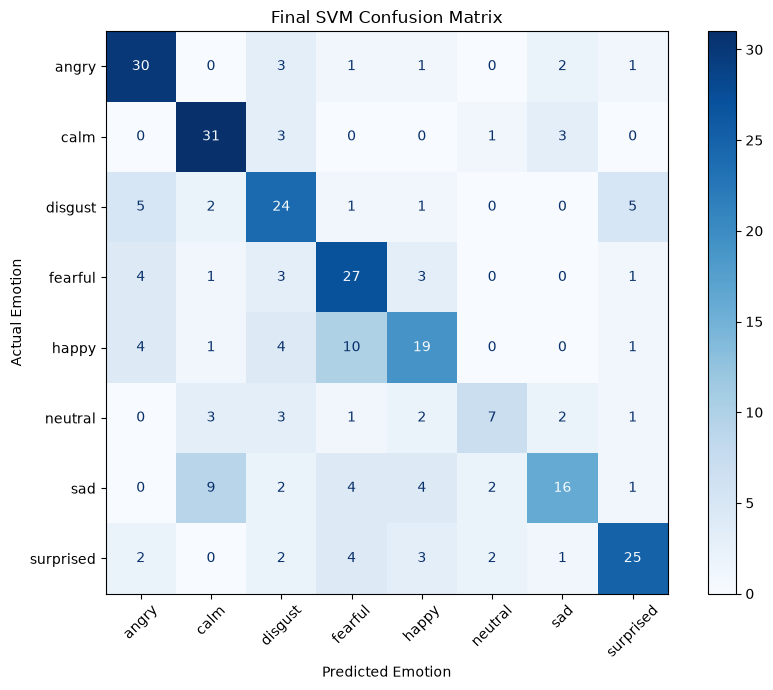

In [14]:
# ----------------------------------------------------------
# CLASSIFICATION REPORT
# ----------------------------------------------------------

print("\nCLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_test,
        y_test_final
    )
)

# ----------------------------------------------------------
# CONFUSION MATRIX
# ----------------------------------------------------------

classes = sorted(y_test.unique())

cm = confusion_matrix(
    y_test,
    y_test_final,
    labels=classes
)

fig, ax = plt.subplots(figsize=(9, 7))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=classes
)

disp.plot(
    ax=ax,
    cmap="Blues",
    values_format="d",
    xticks_rotation=45
)

plt.title("Final SVM Confusion Matrix")
plt.xlabel("Predicted Emotion")
plt.ylabel("Actual Emotion")
plt.tight_layout()
plt.show()

# Save Model

In [15]:
# ----------------------------------------------------------
# SAVE FINAL SVM MODEL
# ----------------------------------------------------------

import joblib

MODEL_PATH = r"D:\SJU\ML assn\CallConnect\final_svm_model.pkl"

joblib.dump(
    final_model,
    MODEL_PATH
)

print("Final SVM model saved successfully.")
print("Path:", MODEL_PATH)

Final SVM model saved successfully.
Path: D:\SJU\ML assn\CallConnect\final_svm_model.pkl


# Verify Model 

In [16]:
# ----------------------------------------------------------
# VERIFY SAVED MODEL
# ----------------------------------------------------------

loaded_model = joblib.load(MODEL_PATH)

test_predictions = loaded_model.predict(X_test)

print("Model loaded successfully.")
print("Predictions match:",
      (test_predictions == y_test_final).all())

Model loaded successfully.
Predictions match: True
